In [1]:
import logging
import sys
from pathlib import Path

sys.path.append(Path.cwd().parent.parent.as_posix())

from utils.logging_and_reporting.logger import setup_logging

# setup logger
setup_logging(logging.DEBUG)


from utils.logging_and_reporting.wandb_api_helper import wandb_retrieve_metrics_for_run

file_path = "/mnt/labstore/bespoke_olap/benchmark_logs/"
# wandb_runs = ["m67to2p5"]  # optim
wandb_runs = [
    ("tpch", "tc2q4e36 "),  # TPCH mt
    ("ceb", "2h03uj74"),  # CEB mt
    ("tpch", "3zdiw9ol "),  # TPCH optim
    ("ceb", "gava9bsh"),  # CEB mt
]  # mt

# lookup snapshot for wandb run
if wandb_runs is not None:
    snapshot_hash = []
    for benchmark, wandb_run in wandb_runs:
        statistics, config, hist = wandb_retrieve_metrics_for_run(
            benchmark=benchmark, run_id=wandb_run, output_hist=True
        )
        snapshot_hash.append(statistics["code/snapshot_hash"])
else:
    snapshot_hash = None

print(f"snapshot hash: {snapshot_hash}")


2026-06-08 14:10:05 DEBUG:asyncio:Using selector: EpollSelector
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/jwehrstein/.netrc.


✓ Run loaded: tpch_mt_q1-22_sonnet-4-6_in_memory_bstorage
  State: finished
  Created: 2026-06-01T11:41:53Z
✓ Data fetched: 5271 turns, 183 columns
✓ Run loaded: ceb_mt_q1a-11b_sonnet-4-6_in_memory_bstorage
  State: finished
  Created: 2026-06-01T12:09:37Z
✓ Data fetched: 5991 turns, 160 columns
✓ Run loaded: tpch_optim_q1-22_sonnet-4-6_in_memory
  State: finished
  Created: 2026-06-01T12:23:36Z
✓ Data fetched: 8310 turns, 179 columns
✓ Run loaded: ceb_optim_q1a-11b_sonnet-4-6_in_memory_bstorage
  State: finished
  Created: 2026-06-01T12:19:14Z
✓ Data fetched: 6336 turns, 152 columns
snapshot hash: ['c9f5c33d5ffda9185b2e12d2741b019690be4f1f', '7d998ac5e3f01162cfa14be32b5332cdbe7f9a03', '69864d1a9d0057e6a94c937e0af569c850c20d60', 'b0b5785e518b50f3b7b2d212c202ab0274122c4b']


In [28]:
import pandas as pd


def file_matches(observed_set: set, expected_set: set | None):
    if expected_set is None:
        return True

    # check if there is overlap between sets
    if observed_set.intersection(expected_set):
        return True

    return False


def get_matching_files(
    sf_list,
    threads_list,
    benchmarks,
    systems,
    snapshot_hash: list[str] | None,
    hostname: str | None,
):
    matching_files = []
    for file in sorted(Path(file_path).glob("*.csv")):
        # load the file to pandas dataframe
        df = pd.read_csv(file)

        # check if any of the conditions hold
        sf_in_file = df["scale_factor"].unique().tolist()
        t_in_file = df["num_threads"].unique().tolist()
        b_in_file = df["benchmark"].unique().tolist()
        s_in_file = df["system"].unique().tolist()
        snapshot_in_file = df["snapshot"].dropna().unique().tolist()
        hostname_in_file = df["hostname"].unique().tolist()

        if not file_matches(set(sf_in_file), set(sf_list)):
            print(f"File {file} does not match sf condition: {sf_in_file} vs {sf_list}")
            continue

        if not file_matches(set(t_in_file), set(threads_list)):
            print(
                f"File {file} does not match threads condition: {t_in_file} vs {threads_list}"
            )
            continue

        if not file_matches(set(b_in_file), set(benchmarks)):
            print(
                f"File {file} does not match benchmark condition: {b_in_file} vs {benchmark}"
            )
            continue

        if not file_matches(set(s_in_file), set(systems)):
            print(
                f"File {file} does not match system condition: {s_in_file} vs {systems}"
            )
            continue

        if len(snapshot_in_file) != 0:
            if snapshot_hash is not None and not file_matches(
                set(snapshot_in_file), set(snapshot_hash)
            ):
                print(
                    f"File {file} does not match snapshot condition: {snapshot_in_file} vs {snapshot_hash}"
                )
                continue

        if hostname is not None and not file_matches(
            set(hostname_in_file), set([hostname])
        ):
            print(
                f"File {file} does not match hostname condition: {hostname_in_file} vs {hostname}"
            )
            continue
        elif hostname is None:
            found_ctr = 0
            for h in hostname_in_file:
                if h.startswith("fn"):
                    found_ctr += 1

            if found_ctr == 0:
                print(
                    f"File {file} does not match hostnames starting with fn: {hostname_in_file}"
                )
                continue

        matching_files.append(file)
    return matching_files


benchmarks = ["tpch", "ceb"]
systems = ["DuckDB", "Clickhouse", "Umbra", "Bespoke"]

sf_plot = False

if sf_plot:
    sf_list = [1, 2, 20]
    threads_list = [1, 16]
else:
    # threads plot
    sf_list = [5, 10, 50, 100]
    threads_list = [2, 4, 8, 32]
# hostname = "fn02"
hostname = None

matching_files = get_matching_files(
    sf_list=sf_list,
    threads_list=threads_list,
    benchmarks=benchmarks,
    systems=systems,
    snapshot_hash=snapshot_hash,
    hostname=hostname,
)

print("Matching files:")
for file in matching_files:
    print(file)

File /mnt/labstore/bespoke_olap/benchmark_logs/20260425_093108_bespoke_tpch.csv does not match snapshot condition: ['f7812dea61f38bf133496790ff0c36326cb90fe5'] vs ['c9f5c33d5ffda9185b2e12d2741b019690be4f1f', '7d998ac5e3f01162cfa14be32b5332cdbe7f9a03', '69864d1a9d0057e6a94c937e0af569c850c20d60', 'b0b5785e518b50f3b7b2d212c202ab0274122c4b']
File /mnt/labstore/bespoke_olap/benchmark_logs/20260429_102250_duckdb_tpch.csv does not match threads condition: [1] vs [2, 4, 8, 32]
File /mnt/labstore/bespoke_olap/benchmark_logs/20260429_113619_umbra_tpch.csv does not match threads condition: [1] vs [2, 4, 8, 32]
File /mnt/labstore/bespoke_olap/benchmark_logs/20260429_124015_clickhouse_tpch.csv does not match threads condition: [1] vs [2, 4, 8, 32]
File /mnt/labstore/bespoke_olap/benchmark_logs/20260601_144410_bespoke_tpch.csv does not match threads condition: [16] vs [2, 4, 8, 32]
File /mnt/labstore/bespoke_olap/benchmark_logs/20260601_145931_bespoke_ceb.csv does not match threads condition: [16] v

In [3]:
# # assemble cmd
# cmd = (
#     "python -m demo_and_analysis.benchmark plot "
#     + " ".join(str(f) for f in matching_files)
#     + " --output plots/plot.png --x scale_factor"
# )
# print("Run the following command to generate the plot:")
# print(cmd)

2026-06-08 15:29:25 INFO:demo_and_analysis.benchmark.plot:Plotting benchmark logs: [PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260429_102250_duckdb_tpch.csv'), PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260429_113619_umbra_tpch.csv'), PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260601_144410_bespoke_tpch.csv'), PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260601_145931_bespoke_ceb.csv'), PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260601_150331_bespoke_ceb.csv'), PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260601_164603_bespoke_tpch.csv'), PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260601_211240_duckdb_ceb.csv'), PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260601_211428_duckdb_tpch.csv'), PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260601_212931_umbra_tpch.csv'), PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260601_213130_umbra_ceb.csv'), PosixPath('/mnt/labstore/bespoke_olap/b

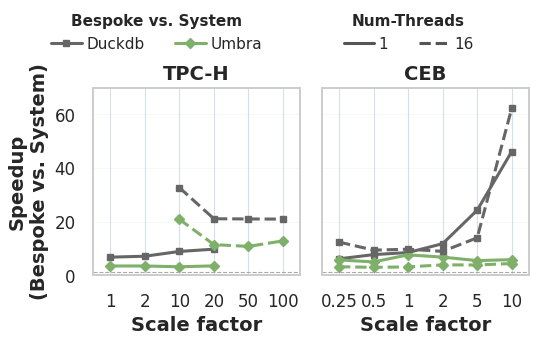

In [26]:
import importlib
from types import SimpleNamespace

import demo_and_analysis.benchmark.plot
import demo_and_analysis.benchmark.plot_by_threads
import utils.logging_and_reporting.logger

importlib.reload(demo_and_analysis.benchmark.plot_by_threads)
importlib.reload(demo_and_analysis.benchmark.plot)
importlib.reload(utils.logging_and_reporting.logger)

from demo_and_analysis.benchmark.plot import plot_logs

plot_args = {
    "logs": matching_files,
    "output": Path().cwd() / "plots" / "plot_sf.pdf",
    "x": "scale_factor",
    # "title": "TPC-H Speedup by Scalefactor",
    "thread_plot_args": {
        "show_speedup": True,  # <-- add this
        "product_plot": True,
        "threads_to_show": [1, 16],
        "show_value_labels": False,
    },
}

# convert to namespace
plot_args_ns = SimpleNamespace(**plot_args)

fig = plot_logs(plot_args_ns, show=True)
assert fig is not None, "Plotting failed, fig is None"

fig.show()

2026-06-08 15:30:50 INFO:demo_and_analysis.benchmark.plot:Plotting benchmark logs: [PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260425_082355_duckdb_tpch.csv'), PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260425_091045_umbra_tpch.csv'), PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260425_095856_duckdb_tpch.csv'), PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260425_113442_umbra_tpch.csv'), PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260601_144252_bespoke_tpch.csv'), PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260601_150019_bespoke_ceb.csv'), PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260601_192216_umbra_ceb.csv'), PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260601_202145_bespoke_tpch.csv'), PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260601_203235_bespoke_ceb.csv'), PosixPath('/mnt/labstore/bespoke_olap/benchmark_logs/20260601_220957_umbra_ceb.csv'), PosixPath('/mnt/labstore/bespoke_olap/be


ceb  [total time (s)]
                      1       2       4       8      16      32      64
---------------  ------  ------  ------  ------  ------  ------  ------
Bespoke (SF 10)    4.94    2.83    1.82    1.32    1.1     1.01    1
Bespoke (SF 5)     2.96    1.75    1.09    0.83    0.69    0.61    0.57
Duckdb (SF 10)   923.06  581.03  367.78  254.23  211.12  195.3   201.84
Duckdb (SF 5)    118.9    66.43   40.55   24.48   19.95   17.44   16.65
Umbra (SF 10)     57.83   29.31   14.62    7.94    4.67    3.17    2.56
Umbra (SF 5)      17.48    9.09    4.5     2.63    1.78    1.45    1.36

tpch  [total time (s)]
                       1       2      4      8     16     32     64
----------------  ------  ------  -----  -----  -----  -----  -----
Bespoke (SF 100)   18.59    9.82   5.58   3.36   2.35   1.75   1.52
Bespoke (SF 50)     8.73    4.54   2.59   1.66   1.17   0.94   0.85
Duckdb (SF 100)   269.1   144.7   71.37  43.27  25.98  23.18  20.84
Duckdb (SF 50)    131.09   71     34.99 

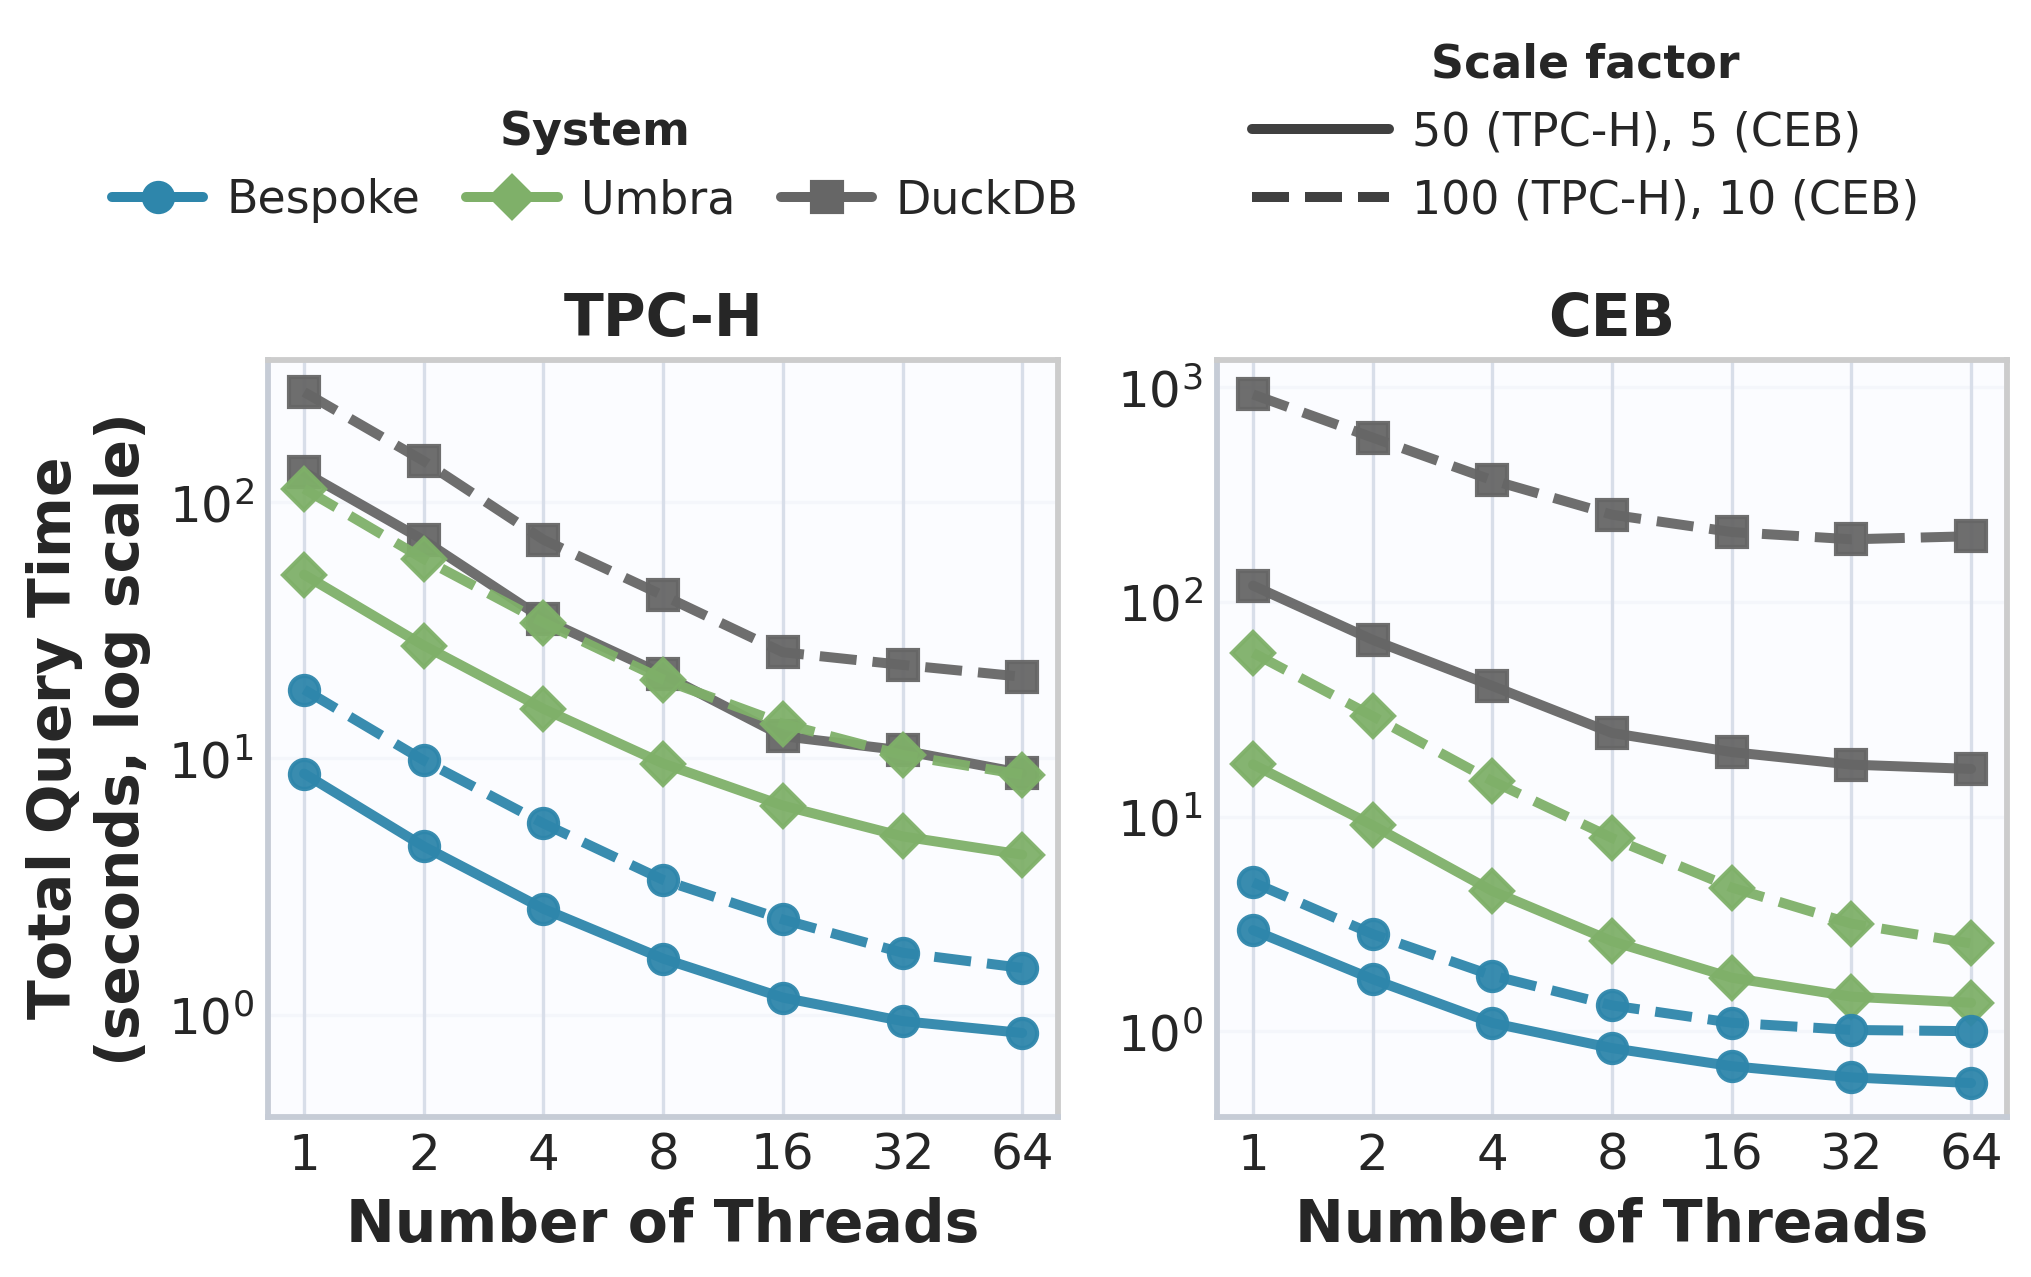

In [29]:
import importlib
from types import SimpleNamespace

import demo_and_analysis.benchmark.plot
import demo_and_analysis.benchmark.plot_by_threads
import utils.logging_and_reporting.logger

importlib.reload(demo_and_analysis.benchmark.plot_by_threads)
importlib.reload(demo_and_analysis.benchmark.plot)
importlib.reload(utils.logging_and_reporting.logger)

from demo_and_analysis.benchmark.plot import plot_logs

plot_args = {
    "logs": matching_files,
    "output": Path().cwd() / "plots" / "plot_num_threads.pdf",
    "x": "num_threads",
    # "title": "TPC-H Speedup by Threads",
    "thread_plot_args": {
        "show_speedup": False,
        "show_runtime": True,
        "max_threads": 64,
        "legend_pos": "up",
        "product_plot": True,
    },
}

# convert to namespace
plot_args_ns = SimpleNamespace(**plot_args)

fig = plot_logs(plot_args_ns, show=True, print_values=True)
assert fig is not None, "Plotting failed, fig is None"

fig.show()